<a href="https://colab.research.google.com/github/mffg1993/TopicsInOptics/blob/main/StructuredLight/Python/N2_Spatial_modes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
# @title **Spatial modes: Higher Order Beams**
import numpy as np
import matplotlib.pyplot as plt
import math

##############################################################################################
# Numerical implementation of the Special functions
##############################################################################################

# --------------------------------------------------------------------------------------------
# Hermite-Gaussian Beams
# --------------------------------------------------------------------------------------------

#Numerical definition of the Hermite Polynomials
def NHermite(n,X):
    Hn1=np.ones(X.shape);
    H=2*X;
    if n<0:
        print('The index must be 0 or positive')
    elif n==0:
        H=Hn1;
    elif n==1:
        H=H;
    else:
        for nn in range(2,n+1):
            Hn=2*X*H-2*(nn-1)*Hn1;
            Hn1=H;
            H=Hn;
    return(H)

# Hermite Gaussian beam where m and ell are the orders in the x and y direction, respectively
def HG(X,Y,m,n,w0):
    h=np.abs(X[0,0]-X[0,1])
    a=NHermite(m,np.sqrt(2)*X/w0)*NHermite(n,np.sqrt(2)*Y/w0)*np.exp(-(X**2+Y**2)/w0**2)
    N=np.sum(h*h*np.abs(a)**2)
    a=a/np.sqrt(N)
    return(a)

# --------------------------------------------------------------------------------------------
# Laguerre-Gaussian Beams
# --------------------------------------------------------------------------------------------

# Numerical Implementation of the Laguerre Polynomials
def NlaguerreL(n,a,X):
  LL=0
  for m in range(n+1):
    LL=LL+((-1)**m)*(math.factorial(n+a))/(math.factorial(n-m)*math.factorial(a+m)*math.factorial(m))*(X**m);
  return(LL)

# Laguerre-Gaussian Beam where ell and p are the azimuthal and radial indexes, respectively
def LG(RHO,PHI,ell,p,w0):
    C=np.sqrt((2*math.factorial(p))/(np.pi*math.factorial(p+np.abs(ell))))*(1/w0)
    return(C*np.exp(-(RHO/w0)**2)*((np.sqrt(2)*RHO/w0)**np.abs(ell))*np.exp(1j*ell*PHI)*NlaguerreL(p,np.abs(ell),2*(RHO/w0)**2))

# --------------------------------------------------------------------------------------------
# Bessel Beams
# --------------------------------------------------------------------------------------------

# --------------------------------------------------------------------------------------------
# Bessel Beams
# --------------------------------------------------------------------------------------------

# --------------------------------------------------------------------------------------------
# Bessel Beams
# --------------------------------------------------------------------------------------------

# Numerical implementation of the Bessel function J_n(x) for integer n
def NBesselJ(n, X, nmax=40):
    if n < 0:
        print('The index must be 0 or positive')
        return np.zeros_like(X, dtype=float)

    JJ = np.zeros_like(X, dtype=float)

    for m in range(nmax):
        JJ = JJ + ((-1)**m / (math.factorial(m) * math.factorial(m+n))) * (X/2)**(2*m+n)

    return(JJ)

def Bessel(RHO, PHI, ell, kr, X=None, Y=None, normalize=False):
    a = NBesselJ(np.abs(ell), kr*RHO) * np.exp(1j*ell*PHI)

    if normalize:
        if X is None or Y is None:
            raise ValueError("X and Y must be provided if normalize=True")

        hx = np.abs(X[0,1] - X[0,0])
        hy = np.abs(Y[1,0] - Y[0,0])
        N = np.sum(np.abs(a)**2) * hx * hy
        a = a / np.sqrt(N)

    return(a)


## **1. Introduction**

The Gaussian beam is the fundamental solution of the paraxial wave equation. Higher-order solutions can be constructed in different coordinate systems, leading in particular to the *Hermite--Gaussian* (HG) and *Laguerre--Gaussian* (LG) beam families. These modes form complete orthogonal sets of solutions and are especially useful for describing structured optical fields.



## **2. Hermite Gaussian Beams**

In Cartesian coordinates, the paraxial wave equation admits the Hermite--Gaussian modes as separable solutions. Their transverse field distribution at a propagation distance $z$ can be written as

\begin{align}
U_{n,m}(x,y,z)&=\frac{1}{w(z)}
H_n\!\left(\frac{\sqrt{2},x}{w(z)}\right)
H_m\!\left(\frac{\sqrt{2},y}{w(z)}\right)
\exp\!\left[-\frac{x^2+y^2}{w^2(z)}\right]\\[2ex]
&\qquad\times\exp\!\left[-\frac{(x^2+y^2)}{2R(z)}\right]
\exp\!\left[i(n+m+1)\zeta(z)\right],
\end{align}

where $H_n$ and $H_m$ are the Hermite polynomials of orders $n$ and $m$, respectively.

The indices $n$ and $m$ determine the number of nodes of the field along the $x$- and $y$-directions. Therefore, Hermite--Gaussian beams exhibit rectangular symmetry, with transverse intensity patterns composed of lobes arranged on a Cartesian grid. The fundamental Gaussian beam is recovered as the special case \(n=m=0\).

A distinctive feature of Hermite--Gaussian modes is that the Gouy phase appears multiplied by the factor $n+m+1$. Thus, higher-order modes accumulate a larger longitudinal phase shift upon propagation. This additional phase plays an important role in resonators, mode transformations, and interference phenomena involving structured light.

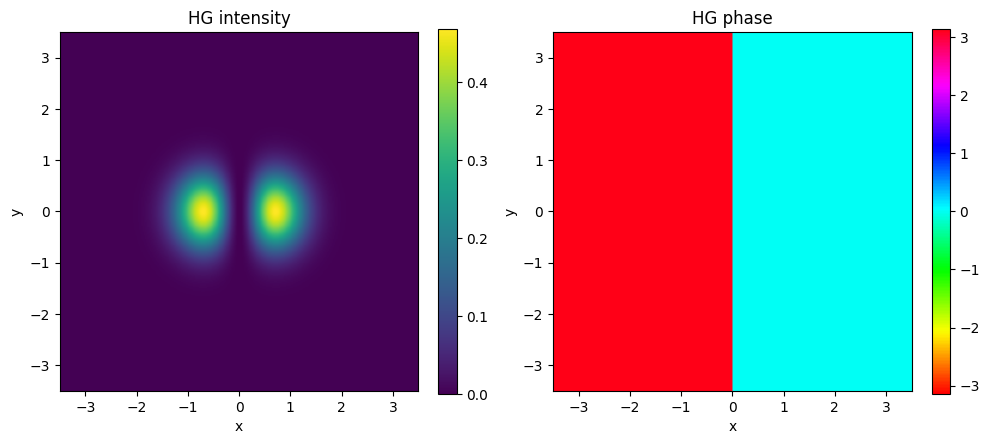

In [7]:
w0=1

# Transverse grid
L = 3.5 * w0
N = 300
x = np.linspace(-L, L, N)
y = np.linspace(-L, L, N)
X, Y = np.meshgrid(x, y)

# Example modes
U_HG = HG(X, Y, m=1, n=0, w0=w0)

I_HG = np.abs(U_HG)**2
PH_HG = np.angle(U_HG)

# =========================
# Hermite-Gaussian figure
# =========================
fig_hg, axes_hg = plt.subplots(1, 2, figsize=(10, 4.5))

im1 = axes_hg[0].imshow(
    I_HG,
    origin="lower",
    extent=[x.min(), x.max(), y.min(), y.max()],
    aspect="equal"
)
axes_hg[0].set_title("HG intensity")
axes_hg[0].set_xlabel("x")
axes_hg[0].set_ylabel("y")
fig_hg.colorbar(im1, ax=axes_hg[0], fraction=0.046)

im2 = axes_hg[1].imshow(
    PH_HG,
    origin="lower",
    extent=[x.min(), x.max(), y.min(), y.max()],
    aspect="equal",
    cmap="hsv",
    vmin=-np.pi,
    vmax=np.pi
)
axes_hg[1].set_title("HG phase")
axes_hg[1].set_xlabel("x")
axes_hg[1].set_ylabel("y")
fig_hg.colorbar(im2, ax=axes_hg[1], fraction=0.046)

plt.tight_layout()
plt.show()




## **3. Laguerre-Gaussian Modes**

In cylindrical coordinates, another important family of solutions of the paraxial wave equation is given by the Laguerre--Gaussian modes. Their transverse field can be written as

\begin{align}
U_{p,\ell}(r,\phi,z)&=
\frac{1}{w(z)}
\left(\frac{\sqrt{2}\,r}{w(z)}\right)^{|\ell|}
L_p^{|\ell|}\!\left(\frac{2r^2}{w^2(z)}\right)
\exp\!\left[-\frac{r^2}{w^2(z)}\right]\\[2ex]
&\qquad \times \exp\!\left[-\frac{ikr^2}{2R(z)}\right]
\exp(i\ell\phi)
\exp\!\left[i(2p+|\ell|+1)\zeta(z)\right],
\end{align}

where $L_p^{|\ell|}$ are the generalized Laguerre polynomials, $p\geq 0$ is the radial index, and $\ell$ is the azimuthal index.

The radial index $p$ determines the number of radial nodes of the field, while the azimuthal index $\ell$ controls the helical phase structure through the factor $\exp(i\ell\phi)$. As a result, Laguerre--Gaussian beams possess cylindrical symmetry and, for $\ell\neq 0$, exhibit a phase singularity at the beam center, producing the characteristic doughnut-shaped intensity profile.

For Laguerre--Gaussian beams, the Gouy phase is weighted by the factor $2p+|\ell|+1$, showing again that higher-order modes acquire a larger phase anomaly during propagation.

An important property of Laguerre--Gaussian beams is that each photon in a mode with azimuthal index $\ell$ carries an orbital angular momentum of $\ell\hbar$. This makes these beams especially relevant in applications involving optical manipulation, communications, quantum optics, and singular optics.

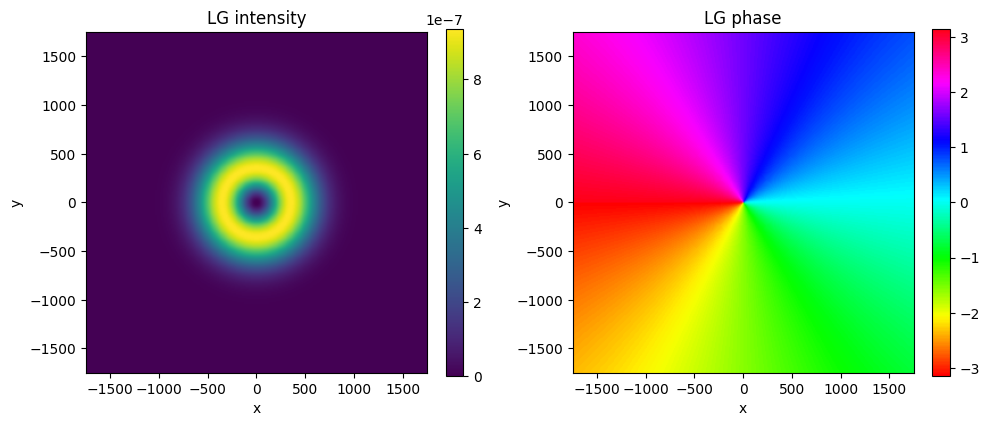

In [ ]:
# Transverse grid
L = 3.5 * w0
N = 300
x = np.linspace(-L, L, N)
y = np.linspace(-L, L, N)
X, Y = np.meshgrid(x, y)

# Polar coordinates for LG modes
RHO = np.sqrt(X**2 + Y**2)
PHI = np.arctan2(Y, X)

# Example modes
U_LG = LG(RHO, PHI, ell=1, p=0, w0=w0)

I_LG = np.abs(U_LG)**2
PH_LG = np.angle(U_LG)


# =========================
# Laguerre-Gaussian figure
# =========================
fig_lg, axes_lg = plt.subplots(1, 2, figsize=(10, 4.5))

im3 = axes_lg[0].imshow(
    I_LG,
    origin="lower",
    extent=[x.min(), x.max(), y.min(), y.max()],
    aspect="equal"
)
axes_lg[0].set_title("LG intensity")
axes_lg[0].set_xlabel("x")
axes_lg[0].set_ylabel("y")
fig_lg.colorbar(im3, ax=axes_lg[0], fraction=0.046)

im4 = axes_lg[1].imshow(
    PH_LG,
    origin="lower",
    extent=[x.min(), x.max(), y.min(), y.max()],
    aspect="equal",
    cmap="hsv",
    vmin=-np.pi,
    vmax=np.pi
)
axes_lg[1].set_title("LG phase")
axes_lg[1].set_xlabel("x")
axes_lg[1].set_ylabel("y")
fig_lg.colorbar(im4, ax=axes_lg[1], fraction=0.046)

plt.tight_layout()
plt.show()

## **X. Diffractionless Beams**

Most optical beams spread as they propagate. This effect, known as diffraction, is a direct consequence of the fact that a localized transverse field contains a distribution of transverse spatial frequencies. As the beam evolves in free space, these components accumulate different phases, causing the transverse profile to broaden with distance. A familiar example is the Gaussian beam, whose width increases steadily away from the waist.

A particularly important class of structured fields is formed by the so-called diffractionless or non-diffracting beams. These are wavefields whose transverse intensity profile remains invariant, or nearly invariant, over propagation. In other words, although the field may acquire an overall phase, its transverse shape does not appreciably change over a certain axial range.



## **Bessel Beams**


The canonical example is the Bessel beam. In its ideal form, the transverse field is proportional to a Bessel function of the first kind,

$$E(\rho,\phi,z) ∝ \text{J}_{l}(k_r \, \rho) e^{i\ell \phi} e^{ik_z z}$$



where $\rho$is the radial coordinate, $\phi$ the azimuthal angle, $\ell$ the topological charge, and $k_r$, $k_z$ are the transverse and longitudinal components of the wavevector, satisfying

$$k^2=k_r^2+k_z^2.$$

The key reason Bessel beams are diffractionless is their structure in momentum space. Rather than being composed of plane waves with a broad range of transverse directions, an ideal Bessel beam is built from plane waves whose wavevectors lie on a cone. Because all these components have the same transverse wavevector magnitude $k_r$, their interference produces a transverse pattern that remains unchanged during propagation. The result is a beam with a bright central core surrounded by concentric rings.

An important feature of Bessel beams is their self-healing behavior. If part of the beam is blocked, the central structure can reappear after some propagation distance. This occurs because the beam is continuously reconstructed from the conical distribution of plane-wave components. This property makes Bessel-like beams useful in applications such as optical trapping, microscopy, laser machining, and propagation through partially obstructed or scattering environments.

Strictly speaking, an ideal diffractionless beam carries infinite energy, since its ring structure extends to infinite radius. Such beams cannot be realized exactly in experiment. What is generated in practice is a finite-aperture approximation, often called a Bessel-like beam. These approximate beams preserve their shape only over a finite propagation interval, often referred to as the non-diffracting range.

From a broader perspective, diffractionless beams are an important example of how the spatial structure of light can be engineered to control propagation. They illustrate that diffraction is not simply “removed,” but rather carefully balanced through interference among appropriately chosen spatial-frequency components.

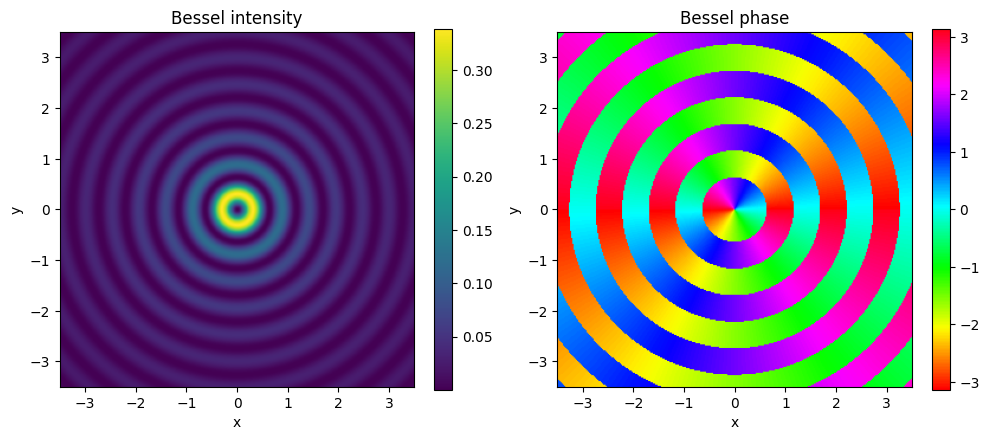

In [16]:
w0=1

# Transverse grid
L = 3.5 * w0
N = 300
x = np.linspace(-L, L, N)
y = np.linspace(-L, L, N)
X, Y = np.meshgrid(x, y)

# Polar coordinates
RHO = np.sqrt(X**2 + Y**2)
PHI = np.arctan2(Y, X)

# Example mode
U_Bessel = Bessel(RHO, PHI, ell=1, kr=6.0)

I_Bessel = np.abs(U_Bessel)**2
PH_Bessel = np.angle(U_Bessel)

# =========================
# Bessel beam figure
# =========================
fig_bessel, axes_bessel = plt.subplots(1, 2, figsize=(10, 4.5))

im1 = axes_bessel[0].imshow(
    I_Bessel,
    origin="lower",
    extent=[x.min(), x.max(), y.min(), y.max()],
    aspect="equal"
)
axes_bessel[0].set_title("Bessel intensity")
axes_bessel[0].set_xlabel("x")
axes_bessel[0].set_ylabel("y")
fig_bessel.colorbar(im1, ax=axes_bessel[0], fraction=0.046)

im2 = axes_bessel[1].imshow(
    PH_Bessel,
    origin="lower",
    extent=[x.min(), x.max(), y.min(), y.max()],
    aspect="equal",
    cmap="hsv",
    vmin=-np.pi,
    vmax=np.pi
)
axes_bessel[1].set_title("Bessel phase")
axes_bessel[1].set_xlabel("x")
axes_bessel[1].set_ylabel("y")
fig_bessel.colorbar(im2, ax=axes_bessel[1], fraction=0.046)

plt.tight_layout()
plt.show()

## Future work

- Elegant Laguerre–Gaussian (eLG) modes – alternative LG definition
- Ince–Gaussian (IG) modes – elliptical symmetry
- Mathieu beams – exact Helmholtz solutions in elliptical coordinates
- Bessel–Gaussian (BG) beams – finite-energy approximations of Bessel beams
- Airy beams – accelerating and self-healing beams